In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Import dataset
import pandas as pd
demographics = pd.read_csv('/content/Telco_customer_churn_demographics.csv', delimiter=';')
services = pd.read_csv('/content/Telco_customer_churn_services.csv', delimiter=';')
status = pd.read_csv('/content/Telco_customer_churn_status(1).csv')

In [ ]:
# Merge demographics, services, and status data
data = demographics.merge(services, on='Customer ID', how='left') \
             .merge(status, on='Customer ID', how='left')

In [ ]:
# Check missing values
data.isnull().sum()

,0
Customer ID,0
Count_x,0
Gender,0
Age,0
Under 30,0
Senior Citizen,0
Married,0
Dependents,0
Number of Dependents,0
Service ID,0


In [ ]:
# Fill NaN in Offer column
data['Offer'].fillna('No Offer', inplace=True)

In [ ]:
# Remove newly joined customers
data1 = data[data['Customer Status'] != 'Joined']

In [ ]:
# Drop unnecessary columns for analytics -> these are identifier and symptoms/result features not churn drivers
df = data1.drop(columns=['Customer ID', 'Count_x',
        'Under 30', 'Senior Citizen', # represented by age
        'Dependents', # represented by number of dependents
        'Service ID', 'Count_y', 'Quarter_x',
        'Referred a Friend', 'Number of Referrals',
        'Total Charges', 'Total Refunds',
        'Total Extra Data Charges', 'Total Long Distance Charges',
        'Total Revenue', 'Status ID', 'Count', 'Quarter_y', 'Satisfaction Score',
        'Satisfaction Score Label', 'Customer Status', 'Churn Value','Churn Score', 'Churn Score Category',
        'CLTV', 'CLTV Category', 'Churn Category', 'Churn Reason'])

df.head()

,Gender,Age,Married,Number of Dependents,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,...,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Churn Label
0,Male,71,No,3,18,Offer D,Yes,11.33,Yes,Yes,...,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,Yes
1,Male,66,Yes,0,58,Offer B,No,0.00,No,Yes,...,No,No,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,45.30,Yes
2,Female,68,No,0,16,Offer D,Yes,9.43,No,Yes,...,Yes,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,94.45,Yes
3,Female,77,No,0,21,No Offer,No,0.00,No,Yes,...,No,Yes,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,41.90,Yes
4,Male,71,Yes,0,27,No Offer,No,0.00,No,Yes,...,No,No,No,No,No,Month-to-Month,No,Credit Card,30.75,Yes


## Classification Analysis

In [ ]:
# Separate target and predictor variables
X = df.drop(['Churn Label'], axis=1)
y = df['Churn Label']

In [ ]:
# Replace Yes/No answer to 1/0
X = X.replace({'Yes': 1, 'No': 0})

# Encode categorical variables: Others
cols = ['Gender', 'Offer', 'Internet Type', 'Contract', 'Payment Method']
category_mappings = {}

for col in cols:
    X[col] = X[col].astype('category')
    category_mappings[col] = dict(enumerate(X[col].cat.categories))
    X[col] = X[col].cat.codes

/tmp/ipykernel_3570/1354825311.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.replace({'Yes': 1, 'No': 0})


In [ ]:
# See mapping result
category_mappings

{'Gender': {0: 'Female', 1: 'Male'},
 'Offer': {0: 'No Offer',
  1: 'Offer A',
  2: 'Offer B',
  3: 'Offer C',
  4: 'Offer D',
  5: 'Offer E'},
 'Internet Type': {0: 'Cable', 1: 'DSL', 2: 'Fiber Optic'},
 'Contract': {0: 'Month-to-Month', 1: 'One Year', 2: 'Two Year'},
 'Payment Method': {0: 'Bank Withdrawal', 1: 'Credit Card', 2: 'Mailed Check'},
 'Phone Internet Service': {0: 'Both Services',
  1: 'Internet Service Only',
  2: 'Phone Service Only'}}

In [ ]:
# Split data into training and testing data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Perform oversampling dengan SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [ ]:
# Perform hyperparameter tuning for Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=42)

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_dt,
    cv=5,
    scoring='recall_macro',
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best DT Params:", grid_dt.best_params_)
best_dt = grid_dt.best_estimator_

# Perform classification task with Decision Tree
from sklearn.metrics import classification_report, confusion_matrix

y_pred_dt = best_dt.predict(X_test)
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Best DT Params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
[[828 116]
 [ 80 294]]
              precision    recall  f1-score   support

          No       0.91      0.88      0.89       944
         Yes       0.72      0.79      0.75       374

    accuracy                           0.85      1318
   macro avg       0.81      0.83      0.82      1318
weighted avg       0.86      0.85      0.85      1318



In [ ]:
# Feature importance analysis
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
18,Contract,0.505871
4,Tenure in Months,0.250347
1,Age,0.081689
3,Number of Dependents,0.077482
21,Monthly Charge,0.077381
15,Streaming Movies,0.007230
2,Married,0.000000
6,Avg Monthly Long Distance Charges,0.000000
5,Offer,0.000000
0,Gender,0.000000


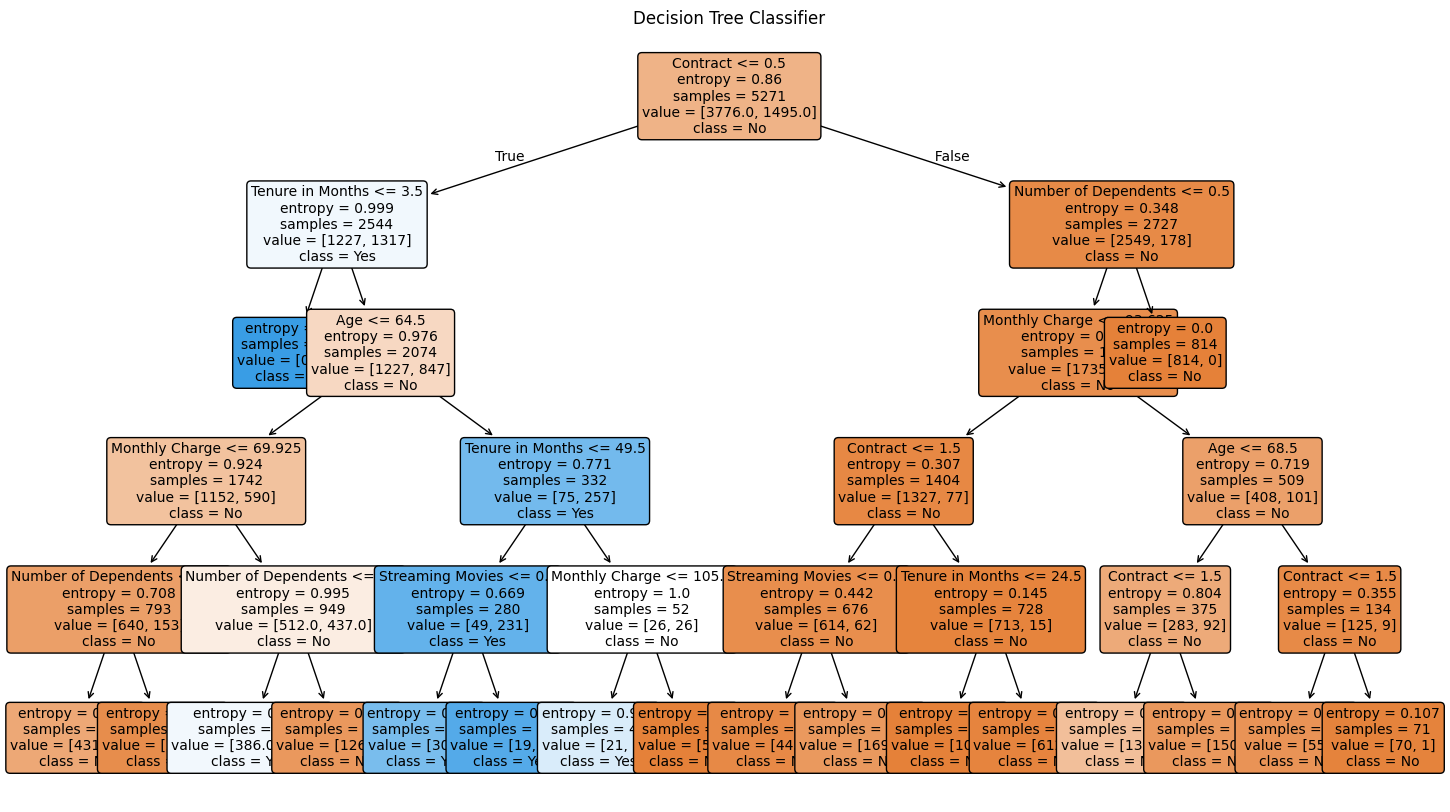

In [ ]:
# Show tree rule
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=best_dt.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Classifier")
plt.show()

In [ ]:
# Show text rule
from sklearn.tree import export_text

rules = export_text(best_dt, feature_names=list(X.columns))
print(rules)

|--- Contract <= 0.50
|   |--- Tenure in Months <= 3.50
|   |   |--- class: Yes
|   |--- Tenure in Months >  3.50
|   |   |--- Age <= 64.50
|   |   |   |--- Monthly Charge <= 69.92
|   |   |   |   |--- Number of Dependents <= 0.50
|   |   |   |   |   |--- class: No
|   |   |   |   |--- Number of Dependents >  0.50
|   |   |   |   |   |--- class: No
|   |   |   |--- Monthly Charge >  69.92
|   |   |   |   |--- Number of Dependents <= 0.50
|   |   |   |   |   |--- class: Yes
|   |   |   |   |--- Number of Dependents >  0.50
|   |   |   |   |   |--- class: No
|   |   |--- Age >  64.50
|   |   |   |--- Tenure in Months <= 49.50
|   |   |   |   |--- Streaming Movies <= 0.50
|   |   |   |   |   |--- class: Yes
|   |   |   |   |--- Streaming Movies >  0.50
|   |   |   |   |   |--- class: Yes
|   |   |   |--- Tenure in Months >  49.50
|   |   |   |   |--- Monthly Charge <= 105.60
|   |   |   |   |   |--- class: Yes
|   |   |   |   |--- Monthly Charge >  105.60
|   |   |   |   |   |--- class: N

# Association Rule Analysis

In [ ]:
# Create subset data containing only service information
data2 = data[['Phone Service', 'Internet Service', 'Online Security', 'Online Backup',
              'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
              'Streaming Movies', 'Streaming Music', 'Unlimited Data']].copy()

# Map Yes/No to 1/0
for col in data2.columns:
    data2[col] = data2[col].map({'Yes': 1, 'No': 0})

data2.head()

,Phone Service,Internet Service,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data
0,1,1,0,0,0,0,1,1,1,1
1,0,1,0,1,1,0,0,1,0,1
2,1,1,0,0,0,1,1,1,1,1
3,0,1,1,0,0,0,1,0,0,1
4,0,1,1,0,0,0,0,0,0,0


In [ ]:
# Filter to only potential cross-selling
warnings.filterwarnings('ignore')

rules_final = rules_core_antecedent[
    (rules_core_antecedent['lift'] > 1) &
    (rules_core_antecedent['confidence'] >= 0.45) &
    (rules_core_antecedent['support'] >= 0.3)
]

rules_final[['antecedents', 'consequents',	'antecedent support',	'consequent support',	'support',	'confidence',	'lift']]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift
8,(Internet Service),(Streaming TV),0.783331,0.384353,0.384353,0.490665,1.276600
10,(Internet Service),(Streaming Movies),0.783331,0.387903,0.387903,0.495197,1.276600
12,(Internet Service),(Streaming Music),0.783331,0.353259,0.353259,0.450970,1.276600
14,(Internet Service),(Unlimited Data),0.783331,0.673719,0.673719,0.860069,1.276600
88,"(Phone Service, Internet Service)",(Streaming TV),0.686497,0.384353,0.343888,0.500931,1.303308
92,"(Phone Service, Internet Service)",(Streaming Movies),0.686497,0.387903,0.345591,0.503413,1.297780
96,"(Phone Service, Internet Service)",(Streaming Music),0.686497,0.353259,0.313503,0.456670,1.292736
100,"(Phone Service, Internet Service)",(Unlimited Data),0.686497,0.673719,0.591509,0.861634,1.278923
102,(Internet Service),"(Phone Service, Unlimited Data)",0.783331,0.591509,0.591509,0.755121,1.276600
